# Разбор поведения cookie

Цель этого ноутбука — понять, какие различия между человеком и ботом стоит превратить в признаки. Строка `train` или `test` — это cookie и одни сутки наблюдения; события этой cookie лежат в `events`.

Сначала проверяем объём и календарь, затем дубли, пропуски, ритм, платформу, объекты, клиент, курсор и час суток. Ноутбук ничего не сохраняет: это короткий разбор исходных данных перед построением признаков.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

datasets = {
    'Train': train,
    'Test': test,
    'Events': events,
}
print(train.shape, test.shape, events.shape)
train.head()


(11091, 5) (4909, 4) (328905, 14)


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


## 1. Объём, классы и календарь

Сначала проверяем долю ботов, пересечение cookie между train и test и календарь. Test идёт после train, поэтому случайное разбиение смешало бы прошлое и будущее.

Последние три дня train — 17–19 апреля. Именно они используются как внешняя проверка перед переходом к неделе test: это самый близкий к test отрезок, который ещё можно проверить с известной меткой.

target
человек    10192
бот          899
Name: count, dtype: int64
доля ботов: 0.0811
общих cookie_id: 0
      window_start_ts            window_end_ts           
                  min        max           min        max
part                                                     
test       2026-04-20 2026-04-26    2026-04-21 2026-04-27
train      2026-04-06 2026-04-19    2026-04-07 2026-04-20
         count  mean  std   min   25%   50%   75%   max
part                                                   
test    4909.0  24.0  0.0  24.0  24.0  24.0  24.0  24.0
train  11091.0  24.0  0.0  24.0  24.0  24.0  24.0  24.0


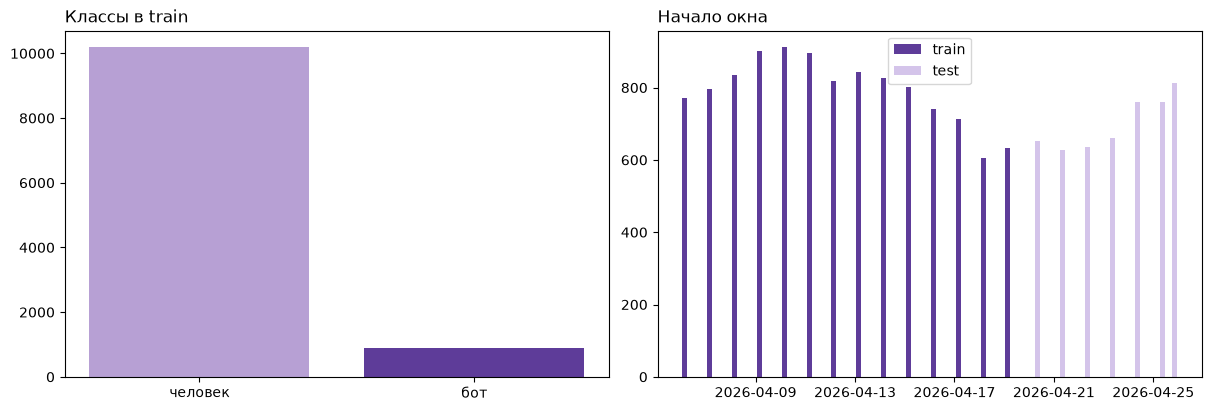

In [2]:
print(train.target.value_counts().rename({0: "человек", 1: "бот"}))
print("доля ботов:", round(train.target.mean(), 4))
print("общих cookie_id:", len(set(train.cookie_id) & set(test.cookie_id)))

span = pd.concat(
    [
        train.assign(part="train"),
        test.assign(part="test"),
    ],
    ignore_index=True,
)
span["hours"] = (span.window_end_ts - span.window_start_ts).dt.total_seconds() / 3600
print(span.groupby("part")[["window_start_ts", "window_end_ts"]].agg(["min", "max"]))
print(span.groupby("part").hours.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
counts = train.target.value_counts().sort_index()
axes[0].bar(["человек", "бот"], counts.values, color=["#b7a0d4", "#5e3c99"])
axes[0].set_title("Классы в train", loc="left")
axes[1].hist(
    [train.window_start_ts, test.window_start_ts],
    bins=40,
    label=["train", "test"],
    color=["#5e3c99", "#d4c4ea"],
)
axes[1].set_title("Начало окна", loc="left")
axes[1].legend()
plt.show()


Ботов 899 из 11091, доля — 0.0811. Общих `cookie_id` между train и test нет.

Окно у всех строк длится 24 часа. Train покрывает 6–19 апреля, test — 20–26 апреля. Проверку модели поэтому строим по времени: более ранние окна обучают, более поздние проверяют.

## 2. Дубли и пропуски

Полный дубль строки в `events` — повтор одного клика. Удаляем дубли со всей таблицы до окна, частот и пауз: иначе один клик посчитается дважды, а пауза между копиями станет нулевой. Разные события с одинаковым временем не склеиваем.


Порядок строк файла не является временем, поэтому перед расчётом пауз события сортируем по `cookie_id` и `event_ts`. 

In [2]:
def check_datasets(datasets: dict):
    report = []

    for name, df in datasets.items():
        rows, cols = df.shape
        dupes = df.duplicated().sum()

        na_counts = df.isna().sum()
        na_counts = na_counts[na_counts > 0].sort_values(ascending=False)

        if not na_counts.empty:
            na_str = "\n".join(
                f"{col}: {val} ({round(val / rows * 100, 1)}%)"
                for col, val in na_counts.items()
            )
        else:
            na_str = "Нет"

        report.append({
            "Датасет": name,
            "Размер (строки, колонки)": f"{rows} x {cols}",
            "Дубликаты": f"{dupes} ({round(dupes / rows * 100, 2)}%)",
            "Пропуски по колонкам": na_str,
        })

    df_report = pd.DataFrame(report)
    return df_report.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})


events_before = len(events)
events = events.drop_duplicates().reset_index(drop=True)
datasets["Events"] = events
print(f"events: удалено {events_before - len(events)} полных дублей, осталось {len(events)}")
display(check_datasets(datasets))
print("События глобально отсортированы по event_ts:", events.event_ts.is_monotonic_increasing)
print(
    "События отсортированы по event_ts внутри каждой cookie_id:",
    events.groupby("cookie_id").event_ts.apply(lambda s: s.is_monotonic_increasing).all(),
)

events: удалено 4863 полных дублей, осталось 324042


,Датасет,"Размер (строки, колонки)",Дубликаты,Пропуски по колонкам
0,Train,11091 x 5,0 (0.0%),Нет
1,Test,4909 x 4,0 (0.0%),Нет
2,Events,324042 x 14,0 (0.0%),search_query: 225113 (69.5%) search_page: 225113 (69.5%) pointer_x: 217076 (67.0%) pointer_y: 217076 (67.0%) seller_type: 131888 (40.7%) item_id: 112938 (34.9%) item_category: 32458 (10.0%) item_location: 23468 (7.2%)


События глобально отсортированы по event_ts: False
События отсортированы по event_ts внутри каждой cookie_id: False


В train и test полных дублей нет. В `events` после очистки удалено 4863 полных дубля, осталось 324042 строки. Таблица исходно не отсортирована ни целиком, ни внутри cookie, поэтому порядок строк не используем.

Пропуски идут парами: `search_query` и `search_page` заполняются для поиска, `pointer_x` и `pointer_y` — только там, где есть координаты. 

## 3. От чего зависит пропуск

Смотрим долю пустых значений по платформе и типу события. Если пропуск связан с устройством или действием, это свойство схемы, а не шум для заполнения.

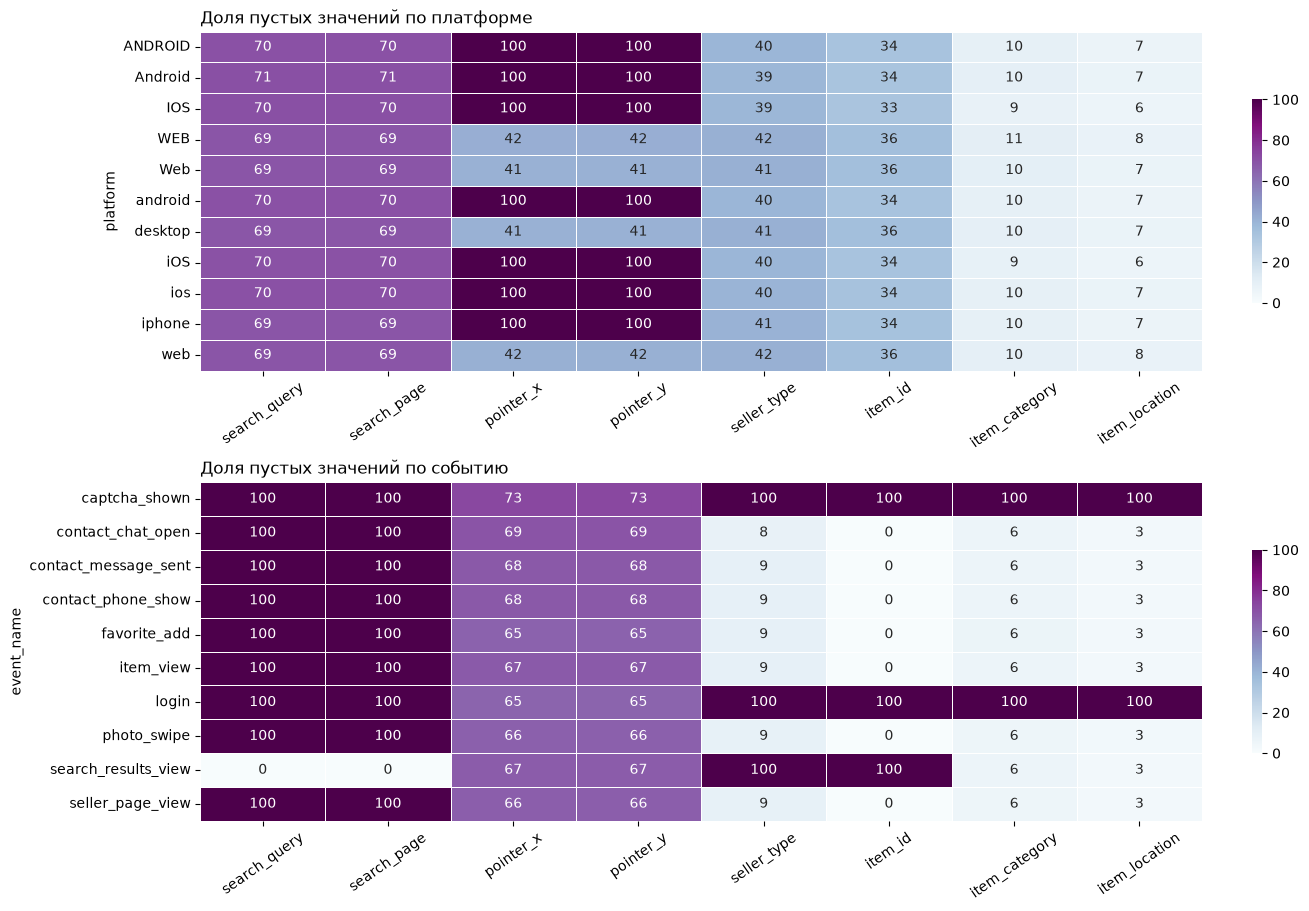

In [4]:
sparse_cols = [
    "search_query",
    "search_page",
    "pointer_x",
    "pointer_y",
    "seller_type",
    "item_id",
    "item_category",
    "item_location",
]

na_flags = events[sparse_cols].isna()
miss_by_platform = na_flags.groupby(events["platform"]).mean().mul(100)
miss_by_event = na_flags.groupby(events["event_name"]).mean().mul(100)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), constrained_layout=True)

for ax, matrix, title, ylabel in (
    (axes[0], miss_by_platform, "Доля пустых значений по платформе", "platform"),
    (axes[1], miss_by_event, "Доля пустых значений по событию", "event_name"),
):
    sns.heatmap(
        matrix,
        ax=ax,
        annot=True,
        fmt=".0f",
        cmap="BuPu",
        vmin=0,
        vmax=100,
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=35)

plt.show()


Платформу на графике нужно читать с учётом таблицы пропусков рядом с ним. Поиск заполняется только для `search_results_view`, поэтому пустые `search_query` и `search_page` в основном отражают тип события. Координаты зависят прежде всего от платформы: на телефонах их нет, а на `web` и `desktop` они есть только у части событий.

`item_id` и `seller_type` также зависят от типа действия. Поэтому эти поля оставляем пропусками и даём модели отличать «поле не применялось» от числового нуля.

## 4. Ритм внутри окна

Используем очищенные события и полуинтервал `[window_start_ts, window_end_ts)`. После сортировки по cookie и времени считаем паузу до предыдущего события той же cookie.

Кроме медианы паузы полезны длительность активности и доли коротких пауз: в FE отдельно считаются шаги короче 30, 1 и 0.3 секунды. Для cookie с одним событием разброс пауз не определён и остаётся пропуском.

events: удалено 0 полных дублей, осталось 324042
        n_events  dt_median  frac_dt_lt60
target                                   
0           12.0       60.5         0.500
1           20.0       25.0         0.842


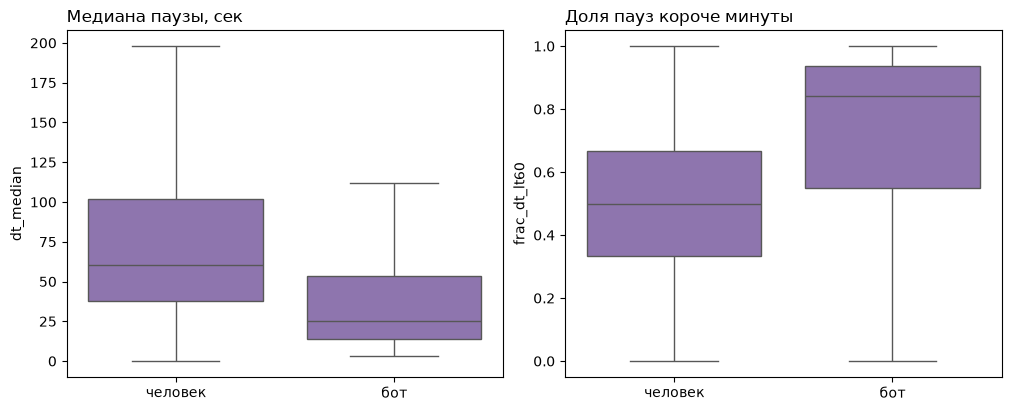

In [3]:
n_before = len(events)
events_model = events.drop_duplicates()
print(f"events: удалено {n_before - len(events_model)} полных дублей, осталось {len(events_model)}")

ev = events_model.merge(
    train[["cookie_id", "window_start_ts", "window_end_ts", "target"]],
    on="cookie_id",
)
ev = ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]
ev = ev.sort_values(["cookie_id", "event_ts"], kind="mergesort")
ev["hour"] = ev.event_ts.dt.hour
ev["dt"] = ev.groupby("cookie_id").event_ts.diff().dt.total_seconds()

gaps = ev.dropna(subset=["dt"])
by_cookie = pd.DataFrame({
    "n_events": ev.groupby("cookie_id").size(),
    "dt_median": gaps.groupby("cookie_id").dt.median(),
    "frac_dt_lt60": gaps.dt.lt(60).groupby(gaps.cookie_id).mean(),
}).join(train.set_index("cookie_id").target)

print(by_cookie.groupby("target")[["n_events", "dt_median", "frac_dt_lt60"]].median().round(3))

plot_df = by_cookie.dropna(subset=["dt_median"]).copy()
plot_df["кто"] = plot_df.target.map({0: "человек", 1: "бот"})
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
sns.boxplot(data=plot_df, x="кто", y="dt_median", ax=axes[0], color="#8d6bb8", showfliers=False)
sns.boxplot(data=plot_df, x="кто", y="frac_dt_lt60", ax=axes[1], color="#8d6bb8", showfliers=False)
axes[0].set_title("Медиана паузы, сек", loc="left")
axes[1].set_title("Доля пауз короче минуты", loc="left")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
plt.show()


У бота медиана числа событий выше: 20 против 12. Медиана паузы ниже: 25 секунд против 60.5. Доля пауз короче минуты — 0.842 у бота против 0.500 у человека.

Это поддерживает признаки плотности действий, длительности окна и нескольких порогов паузы. Одна средняя пауза была бы слишком грубой сводкой.

## 5. Платформа

Платформу приводим к нижнему регистру. Доля ботов считается на уровне cookie: одна cookie имеет один `target`, даже если в окне было много событий. Рядом показываем медиану числа событий на cookie.

Красная линия — доля ботов во всём train. Она нужна как базовая точка для сравнения платформ.

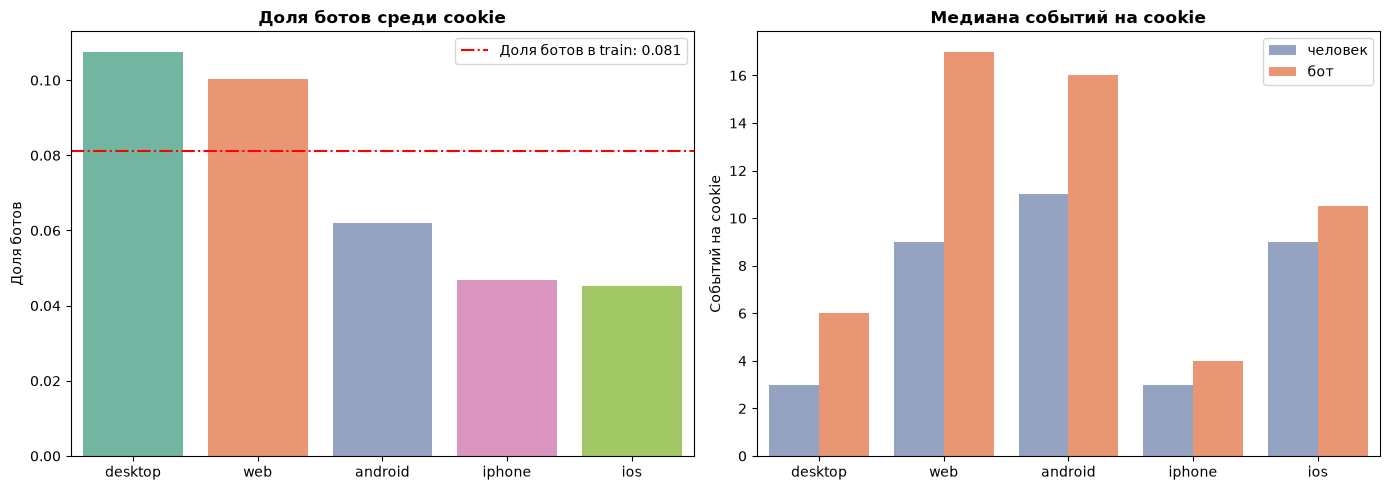

,platform_clean,cookie_count,bot_rate
0,desktop,5270,0.107590
1,web,5866,0.100239
2,android,4595,0.062024
3,iphone,513,0.046784
4,ios,575,0.045217


,platform_clean,class,n
0,android,бот,16.0
1,android,человек,11.0
2,desktop,бот,6.0
3,desktop,человек,3.0
4,ios,бот,10.5
5,ios,человек,9.0
6,iphone,бот,4.0
7,iphone,человек,3.0
8,web,бот,17.0
9,web,человек,9.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ev["platform_clean"] = ev["platform"].astype(str).str.lower()
cookie_platform = (
    ev.groupby(["cookie_id", "platform_clean", "target"], as_index=False)
    .size()
    .rename(columns={"size": "n"})
)
plat = (
    cookie_platform.groupby("platform_clean")
    .agg(cookie_count=("cookie_id", "nunique"), bot_rate=("target", "mean"))
    .reset_index()
)
order = plat.sort_values("bot_rate", ascending=False).platform_clean
plat = plat.set_index("platform_clean").loc[order].reset_index()

sns.barplot(
    data=plat, x="platform_clean", y="bot_rate", hue="platform_clean",
    order=order, ax=axes[0], palette="Set2", legend=False,
)
axes[0].axhline(
    train.target.mean(), color="red", linestyle="-.",
    label=f"Доля ботов в train: {train.target.mean():.3f}",
)
axes[0].set_title("Доля ботов среди cookie", fontweight="bold")
axes[0].set_ylabel("Доля ботов")
axes[0].set_xlabel("")
axes[0].legend()

counts = cookie_platform.copy()
counts["class"] = counts.target.map({0: "человек", 1: "бот"})
med = counts.groupby(["platform_clean", "class"], as_index=False).n.median()
sns.barplot(
    data=med, x="platform_clean", y="n", hue="class",
    order=order, hue_order=["человек", "бот"],
    ax=axes[1], palette=["#8da0cb", "#fc8d62"],
)
axes[1].set_title("Медиана событий на cookie", fontweight="bold")
axes[1].set_ylabel("Событий на cookie")
axes[1].set_xlabel("")
axes[1].legend(title="")

plt.tight_layout()
plt.show()
display(plat)
display(med)

В таблице рядом с графиком видны размеры групп и доля ботов по каждой платформе. Медиана событий показывает, что бот обычно активнее человека на `web`, `desktop` и `android`; небольшие мобильные группы лучше не трактовать отдельно от их размера.

Платформа — один из сигналов, но не самостоятельное правило классификации.

## 6. Разнообразие объектов

Число событий можно набрать повторами одного объявления. Считаем уникальные объявления, категории, запросы и страницы выдачи по cookie; пропуск отдельным объектом не считается.

Эта таблица нужна не только для общего описания. На её основе строятся признаки каталога, глубины поиска и части воронки.

        unique_items  unique_categories  unique_queries  unique_search_pages
target                                                                      
0                6.0                2.0             3.0                  2.0
1               10.0                2.0             4.0                  4.0


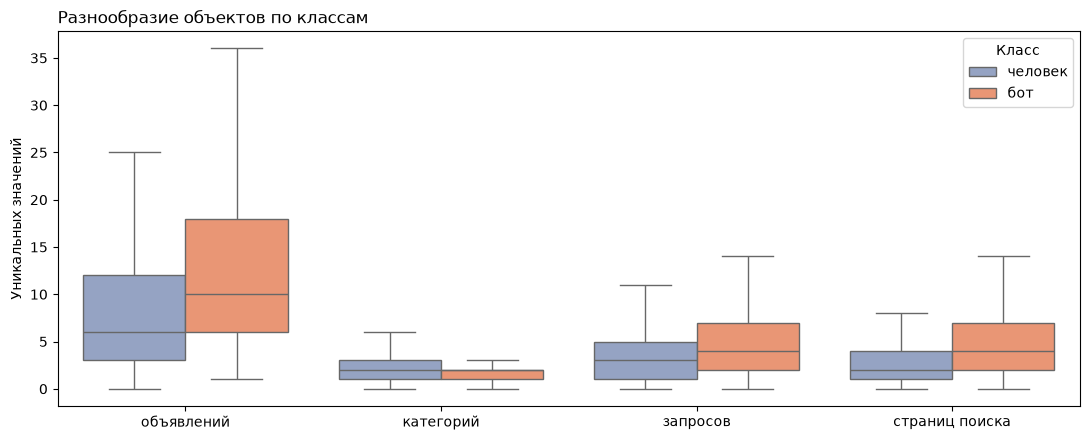

In [7]:
diversity_cols = {
    "unique_items": "item_id",
    "unique_categories": "item_category",
    "unique_queries": "search_query",
    "unique_search_pages": "search_page",
}

diversity = pd.DataFrame(index=ev.cookie_id.unique())
for feature_name, source_col in diversity_cols.items():
    diversity[feature_name] = ev.groupby("cookie_id")[source_col].nunique()

diversity = diversity.join(train.set_index("cookie_id").target)
print(diversity.groupby("target").median().round(2))

plot_diversity = diversity.melt(
    id_vars="target", var_name="Признак", value_name="Уникальных значений"
)
plot_diversity["Класс"] = plot_diversity.target.map({0: "человек", 1: "бот"})
plot_diversity["Признак"] = plot_diversity["Признак"].map({
    "unique_items": "объявлений",
    "unique_categories": "категорий",
    "unique_queries": "запросов",
    "unique_search_pages": "страниц поиска",
})

plt.figure(figsize=(11, 4.5))
sns.boxplot(
    data=plot_diversity,
    x="Признак", y="Уникальных значений", hue="Класс",
    hue_order=["человек", "бот"], palette=["#8da0cb", "#fc8d62"],
    showfliers=False,
)
plt.title("Разнообразие объектов по классам", loc="left")
plt.xlabel("")
plt.tight_layout()
plt.show()


Бот смотрит больше объявлений (медиана 10 против 6), запросов (4 против 3) и страниц выдачи (4 против 2). Медиана числа категорий совпадает, но это не означает, что `category_nunique` бесполезен: хвосты и сочетания с другими признаками всё ещё может использовать модель.

В FE поэтому остаются и простые количества, и признаки глубины поиска. Вывод относится к распределениям, а не к одному жёсткому правилу.

## 7. Клиент

`user_agent` почти уникален, поэтому в EDA показываем понятные семейства и сохраняем три бинарных флага: headless-клиент, скриптовая библиотека и приложение. Сырая строка агента в модель не передаётся.

Число cookie с несколькими `user_agent` также важно проверить: смена агента внутри одного окна — отдельный сигнал, но не доказательство бота.

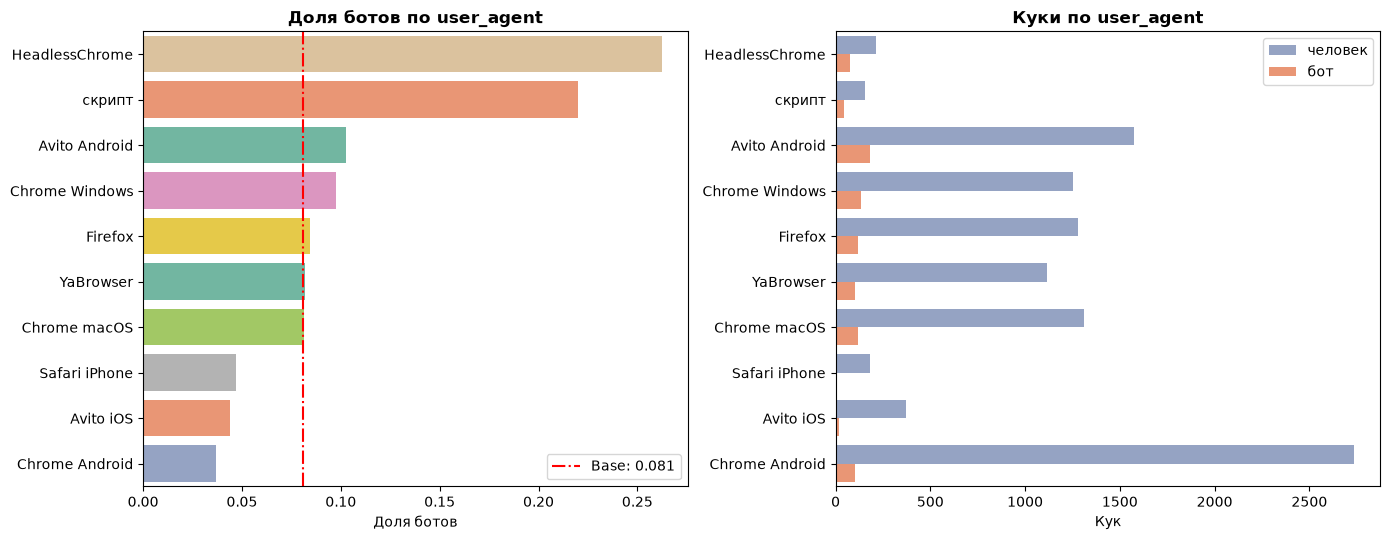

,family,count,mean
0,Avito Android,1754,0.102623
1,Avito iOS,387,0.043928
2,Chrome Android,2841,0.036959
3,Chrome Windows,1387,0.097332
4,Chrome macOS,1427,0.081289
5,Firefox,1399,0.084346
6,HeadlessChrome,286,0.262238
7,Safari iPhone,192,0.046875
8,YaBrowser,1218,0.082102
9,скрипт,200,0.220000


,family,class,n
0,Avito Android,бот,180
1,Avito Android,человек,1574
2,Avito iOS,бот,17
3,Avito iOS,человек,370
4,Chrome Android,бот,105
5,Chrome Android,человек,2736
6,Chrome Windows,бот,135
7,Chrome Windows,человек,1252
8,Chrome macOS,бот,116
9,Chrome macOS,человек,1311


In [8]:
def ua_family(s):
    s = str(s)
    if "Headless" in s:
        return "HeadlessChrome"
    if s.startswith(("curl/", "python-", "node-fetch", "Scrapy", "Go-http")):
        return "скрипт"
    if s.startswith("Avito/") and "Android" in s:
        return "Avito Android"
    if s.startswith("Avito/") and "iPhone" in s:
        return "Avito iOS"
    if "YaBrowser" in s:
        return "YaBrowser"
    if "Firefox" in s:
        return "Firefox"
    if "iPhone" in s:
        return "Safari iPhone"
    if "Android" in s:
        return "Chrome Android"
    if "Macintosh" in s:
        return "Chrome macOS"
    if "Windows" in s:
        return "Chrome Windows"
    return "другое"

ua_counts = ev.groupby(["cookie_id", "user_agent"]).size().rename("n").reset_index()
ua_counts = ua_counts.sort_values(["cookie_id", "n"], ascending=[True, False])
ua_mode = ua_counts.drop_duplicates("cookie_id").set_index("cookie_id").user_agent
ua_df = pd.DataFrame({"user_agent": ua_mode}).join(train.set_index("cookie_id").target)
ua_df["family"] = ua_df.user_agent.map(ua_family)
ua_df["class"] = ua_df.target.map({0: "человек", 1: "бот"})

fam = ua_df.groupby("family").target.agg(count="count", mean="mean").reset_index()
order = fam.sort_values("mean", ascending=False).family

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(
    data=fam, y="family", x="mean", hue="family",
    order=order, ax=axes[0], palette="Set2", legend=False,
)
axes[0].axvline(
    train.target.mean(), color="red", linestyle="-.",
    label=f"Base: {train.target.mean():.3f}",
)
axes[0].set_title("Доля ботов по user_agent", fontweight="bold")
axes[0].set_xlabel("Доля ботов")
axes[0].set_ylabel("")
axes[0].legend()

cls = ua_df.groupby(["family", "class"]).size().rename("n").reset_index()
sns.barplot(
    data=cls, y="family", x="n", hue="class",
    order=order, hue_order=["человек", "бот"],
    ax=axes[1], palette=["#8da0cb", "#fc8d62"],
)
axes[1].set_title("Куки по user_agent", fontweight="bold")
axes[1].set_xlabel("Кук")
axes[1].set_ylabel("")
axes[1].legend(title="")

plt.tight_layout()
plt.show()
display(fam)
display(cls)


Эта разбивка описывает семейства `user_agent`; размер каждой группы напечатан рядом с графиком. Headless и скриптовые клиенты заметно меньше основной массы, поэтому их доли нельзя читать без числа cookie.

Для модели эти семейства сводятся к флагам `is_headless_max`, `is_crawler_lib_max` и `is_avito_app_max`. Отдельно считаем cookie, у которых за окно было больше одного агента.

## 8. Курсор

Координаты есть главным образом у `web` и `desktop`. Считаем скорость на шагах короче минуты, разброс x и y и изменение направления. Последний показатель проверяем как диагностический и не добавляем, если классы не отличаются.

координаты есть у 4046 кук из 11091, среди них ботов: 251
        speed_median   x_std   y_std      x_var  turn_abs_median  rev_frac
target                                                                    
0              31.63  552.90  308.64  305696.56             2.32      0.33
1              17.16  202.54  200.57   41022.30             2.32      0.37
дисперсия x = (медиана std)^2:
target
0    3.1e+05
1    4.1e+04
Name: x_std, dtype: str


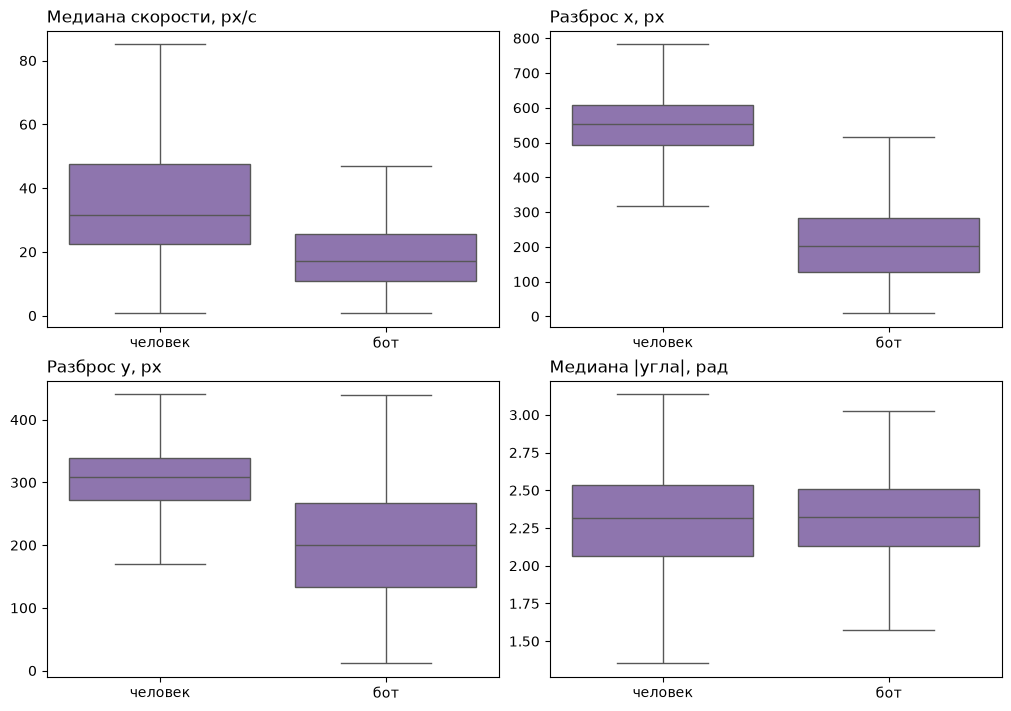

In [9]:
pts = (
    ev.dropna(subset=["pointer_x", "pointer_y"])
    .sort_values(["cookie_id", "event_ts"])
    .copy()
)
g = pts.groupby("cookie_id")
pts["dx"] = g.pointer_x.diff()
pts["dy"] = g.pointer_y.diff()
pts["dt"] = g.event_ts.diff().dt.total_seconds()
pts["dist"] = np.hypot(pts.dx, pts.dy)
pts["speed"] = pts.dist / pts.dt.where((pts.dt > 0) & (pts.dt < 60))
pts["heading"] = np.atan2(pts.dy, pts.dx).where(pts.dist > 0)
pts["turn"] = np.atan2(np.sin(g.heading.diff()), np.cos(g.heading.diff()))

n_with_coords = pts.cookie_id.nunique()
n_bots = int(pts.drop_duplicates("cookie_id").target.sum())
print(f"координаты есть у {n_with_coords} кук из {len(train)}, среди них ботов: {n_bots}")

feat = pd.DataFrame({
    "speed_median": pts.groupby("cookie_id").speed.median(),
    "x_std": g.pointer_x.std(),
    "y_std": g.pointer_y.std(),
    "x_var": g.pointer_x.var(),
    "turn_abs_median": pts.turn.abs().groupby(pts.cookie_id).median(),
    "rev_frac": pts.turn.abs().gt(2.5).groupby(pts.cookie_id).mean(),
}).join(train.set_index("cookie_id").target)
med = feat.groupby("target").median()
print(med.round(2))
print("дисперсия x = (медиана std)^2:")
print((med.x_std ** 2).map(lambda v: f"{v:.1e}"))

feat["кто"] = feat.target.map({0: "человек", 1: "бот"})
metrics = [
    ("speed_median", "Медиана скорости, px/с"),
    ("x_std", "Разброс x, px"),
    ("y_std", "Разброс y, px"),
    ("turn_abs_median", "Медиана |угла|, рад"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for ax, (col, title) in zip(axes.ravel(), metrics):
    sns.boxplot(
        data=feat.dropna(subset=[col]),
        x="кто", y=col, ax=ax,
        order=["человек", "бот"],
        color="#8d6bb8", showfliers=False,
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()


Координаты есть у 4046 cookie из 11091, среди них 251 бот. Медиана скорости — 17.16 px/с у бота и 31.63 у человека; медиана std по x — 202.54 против 552.90, по y — 200.57 против 308.64. Медиана модуля угла одинакова, 2.32 радиана, поэтому угол в признаки не берём.

Сохраняем разброс координат и медианную скорость. Пропуски координат не заменяем нулём.

## 9. Час суток

Смотрим распределение событий по часам. Час события и час создания cookie — разные признаки: первый описывает активность в окне, второй считается от `cookie_created_at`

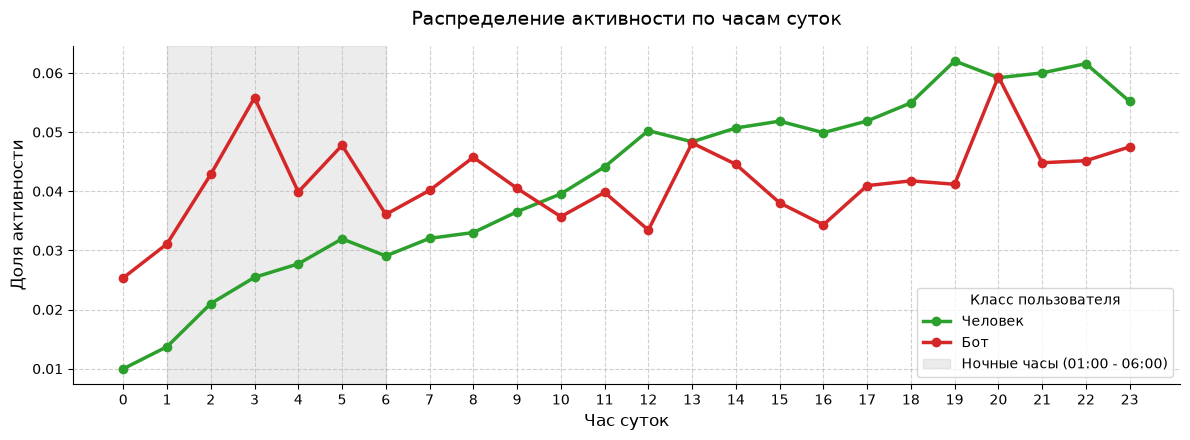

In [10]:
hour_pivot = pd.crosstab(ev['hour'], ev['target'], normalize='columns')
hour_pivot.columns = ['Человек', 'Бот'] 


ax = hour_pivot.plot(
    kind='line', 
    figsize=(12, 4.5), 
    marker='o',            
    linewidth=2.5,          
    color=['#2ca02c', '#d62728'] 
)

ax.set_title('Распределение активности по часам суток', fontsize=14, pad=15)
ax.set_xlabel('Час суток', fontsize=12)
ax.set_ylabel('Доля активности', fontsize=12)

ax.set_xticks(range(0, 24))

ax.grid(True, linestyle='--', alpha=0.6)

ax.axvspan(1, 6, color='gray', alpha=0.15, label='Ночные часы (01:00 - 06:00)')

ax.legend(title='Класс пользователя')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout() 
plt.show()


У людей активность нарастает утром, держится днём и выше вечером. У ботов выше доля событий в интервале 01:00–06:00. Этот интервал используется для `night_events_ratio`; час создания cookie нужно читать отдельно от графика активности.

## Что из этого следует

Ботов мало, cookie между train и test не повторяются, а test идёт после train. Поэтому качество модели проверяем по времени, а не случайным split.

Полные дубли удаляем до окна, пауз и частот. Пропуски координат и полей поиска сохраняем: они отражают схему событий и платформу, а не числовой ноль.

В признаки берём ритм, активность, глубину поиска, объекты, платформу, клиентские флаги, возраст cookie и курсор. Число категорий по медиане не различается, но оставляем его как часть общей матрицы: модель может использовать хвосты и сочетания признаков. Угол поворота курсора в модель не включаем.